# Karplus-Strong


Using delay-line inital conditions to "pluck" the string consisting of random numbers, or white noise. The inital shape of the string is obtained by adding the upper and lower delay lines, we also apply a low-pass filter by taking the average of adjacent samples to obtain:  $$y(n) = 0.5(y(n-N) + y(n-N-1))$$ where $N$ is the sample length. Pitch is determined by $$ f \approx fs / (N+0.5)$$ where $fs$ is the sample rate, set to $44100$ by standard. Without the 2-point average, a raw looped buffer is exactly $ fs/ N$.

In [1]:
%matplotlib inline
import numpy as np, wave, struct
import matplotlib.pyplot as plt
from IPython.display import Audio

In [2]:
fs = 44100 #sample rate
N = 100 # delay-line length
duration = 2.0

In [3]:
noise = np.random.uniform(-1,1, N) #White noise initial state
output = np.zeros(int(fs * duration))
output[0] = noise[0]
idx = 0
last = 0

for i in range(int(fs * duration)):
    output[i] = noise[idx]
    x = noise[idx]
    noise[idx] = 0.5 * (x + last)
    last = x 
    idx = (idx + 1) % N


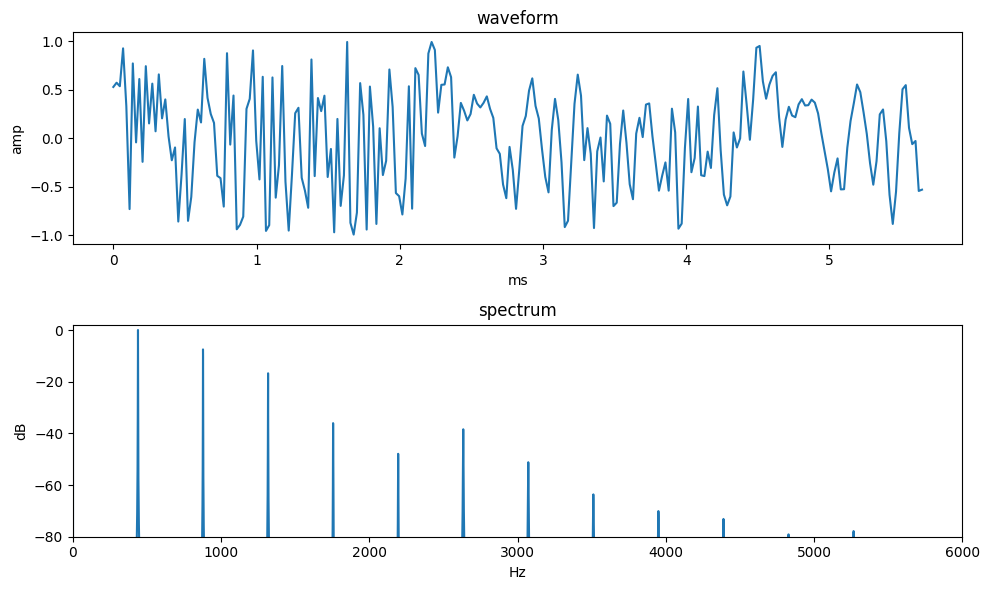

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# waveform, zoomed in — you should SEE a pattern repeating every N samples
t_ms = np.arange(len(output)) / fs * 1000
ax[0].plot(t_ms[:250], output[:250])
ax[0].set_title('waveform')
ax[0].set_xlabel('ms'); ax[0].set_ylabel('amp')

# spectrum — evenly spaced peaks = the harmonics of ~441 Hz
X = np.abs(np.fft.rfft(output * np.hanning(len(output))))
f = np.fft.rfftfreq(len(output), 1/fs)
ax[1].plot(f, 20*np.log10(X/np.max(X) + 1e-9))
ax[1].set_xlim(0, 6000); ax[1].set_ylim(-80, 2)
ax[1].set_title('spectrum'); ax[1].set_xlabel('Hz'); ax[1].set_ylabel('dB')

plt.tight_layout(); plt.show()

In [5]:
Audio(output, rate = fs)

## The Pluck
The pluck is a triangular initial state at a point on the string. Each harmonic $n$ has a fixzed spatil shape along the string with nodes at $ x = L * k/n$. 

In [6]:
#The pluck is an initial state that peaks at a point on the string and decays linearly
beta = 0.5
p = int(beta *N) 
increasing = np.linspace(0, 1, p) 
decreasing = np.linspace(0,1, N-p)
np.concatenate((decreasing,increasing), axis = none)
               
output = np.zeros(int(fs * duration))
output[0] = noise[0]
idx = 0
last = 0

for i in range(int(fs * duration)):
    output[i] = noise[idx]
    x = noise[idx]
    noise[idx] = 0.5 * (x + last)
    last = x 
    idx = (idx + 1) % N


Reference: https://ccrma.stanford.edu/~jos/pasp/Karplus_Strong_Algorithm.html